# ISO 20414:2020 — Test 6: Horizontal counter-flows

Two 10 m x 10 m rooms joined by a 10 m x 2 m corridor (ISO 20414:2020 Table 7). 100 occupants move from room 1 to room 2; the test is repeated with 0, 10, 50 and 100 counter-flow agents moving the other way. The time for room-1 agents to reach room 2 should increase with counter-flow.

In [1]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 30 May 2026, 20:35 UTC


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pedpy
from shapely.geometry import Point, Polygon

from jupedsim_scenarios import load_scenario, run_scenario

In [3]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

## Run each counter-flow branch

ISO Test 6 expects the crossing time to rise with counter-flow. For each counter-flow level we record the number of room-1 agents that reach room 2 (x >= 20 m) and their mean transit time. At high counter-flow CollisionFreeSpeedModel forms no lanes and the primary crowd deadlocks, so those agents never reach room 2.

In [4]:
CF_ZIPS = {0: 'Iso-06-counterflow-0.zip', 10: 'Iso-06-counterflow-10.zip',
           50: 'Iso-06-counterflow-50.zip', 100: 'Iso-06-counterflow-100.zip'}
MAX_TIME = {0: 400, 10: 500, 50: 400, 100: 400}
results = []
for cf, zip_name in CF_ZIPS.items():
    scenario = load_scenario(str(Path('scenario_files') / zip_name))
    scenario.set_max_time(MAX_TIME[cf])
    r = run_scenario(scenario, seed=42)
    df = r.trajectory_dataframe()
    primary = {int(aid) for aid, sub in df.sort_values(['id', 'frame']).groupby('id')
               if sub.iloc[0].x < 5.0}
    reached_room2, full_exit = [], []
    for aid in primary:
        sub = df[df.id == aid].sort_values('frame')
        r2 = sub[sub.x >= 20.0]; fe = sub[sub.x >= 29.7]
        if len(r2): reached_room2.append(r2.iloc[0].frame / r.frame_rate)
        if len(fe): full_exit.append(fe.iloc[0].frame / r.frame_rate)
    results.append({'counterflow': cf, 'primary': len(primary),
                    'reached_room2': len(reached_room2),
                    'mean_reach_room2_s': float(np.mean(reached_room2)) if reached_room2 else float('nan'),
                    'evacuated_full': len(full_exit)})
    r.cleanup()
transit = pd.DataFrame(results)
transit

,counterflow,primary,reached_room2,mean_reach_room2_s,evacuated_full
0,0,100,100,30.239,19
1,10,100,100,47.761,10
2,50,100,0,NaN,0
3,100,100,0,NaN,0


## Plot mean transit time and completion vs counter-flow

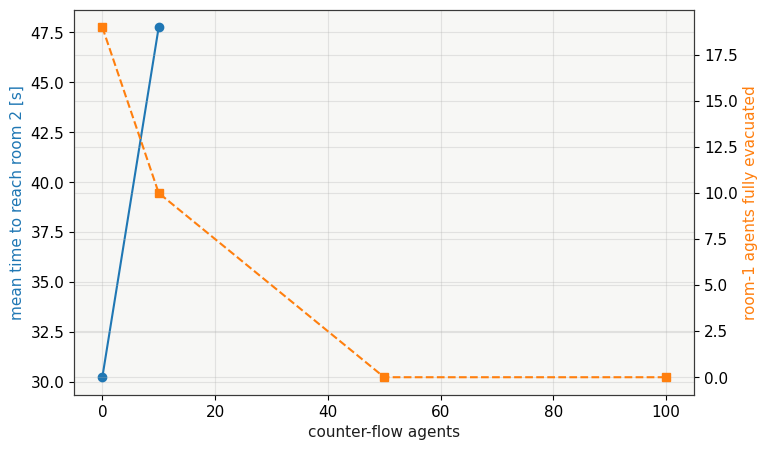

In [5]:
fig, ax1 = plt.subplots()
ax1.plot(transit['counterflow'], transit['mean_reach_room2_s'], 'o-', color='tab:blue')
ax1.set_xlabel('counter-flow agents'); ax1.set_ylabel('mean time to reach room 2 [s]', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(transit['counterflow'], transit['evacuated_full'], 's--', color='tab:orange')
ax2.set_ylabel('room-1 agents fully evacuated', color='tab:orange')
plt.show()

## Acceptance — FAIL

ISO 20414:2020 Test 6 expects the recorded crossing time to **increase** as the number of counter-flow agents rises, which requires the primary crowd to actually reach room 2. CollisionFreeSpeedModel forms no lanes: at >= 50 counter-flow agents the crowd deadlocks and **0 of 100** primary agents reach room 2, so no crossing time exists and the expected increase cannot be produced. The model therefore **fails** ISO Test 6.

ISO 20414:2020 directs that "if conditions of long-term blocking occur during the simulations, this should be documented" — this notebook is that record. Counter-flow with lane formation requires JuPedSim's AnticipationVelocityModel, not the CollisionFreeSpeedModel used here.

In [6]:
reached = transit['reached_room2'].to_numpy()
primary = transit['primary'].to_numpy()
stuck = transit.loc[reached < primary, 'counterflow'].tolist()
print('reached room 2 (x>=20) / primary:', [f'{r}/{p}' for r, p in zip(reached, primary)])
print('mean time to room 2 [s]:', transit['mean_reach_room2_s'].to_numpy())
verdict = 'FAIL' if stuck else 'PASS'
print(f'\nRESULT: {verdict} - ISO 20414:2020 Test 6 (horizontal counter-flows)')
if stuck:
    print(f'Primary crowd deadlocks at counter-flow level(s) {stuck}: agents get stuck')
    print('and never reach room 2, so the ISO-expected crossing-time increase cannot')
    print('be produced. Documented CollisionFreeSpeedModel no-lane-formation limit.')

reached room 2 (x>=20) / primary: ['100/100', '100/100', '0/100', '0/100']
mean time to room 2 [s]: [30.239 47.761    nan    nan]

RESULT: FAIL - ISO 20414:2020 Test 6 (horizontal counter-flows)
Primary crowd deadlocks at counter-flow level(s) [50, 100]: agents get stuck
and never reach room 2, so the ISO-expected crossing-time increase cannot
be produced. Documented CollisionFreeSpeedModel no-lane-formation limit.
